# Week 2 — Models and null models

We shuffle-test every number we published in week 1. This notebook produces
every figure and every number in [the week 2 post](../weeks/week2/week2.html).

**The question throughout:** would a network with no structure beyond the
obvious have given us this anyway?

Two baselines:

| null | what it keeps | what it randomises |
|---|---|---|
| `G(n, m)` | node count, edge count | everything else — no hubs at all |
| degree-preserving shuffle | every node's exact degree | who links to whom |

A quantity that is extreme against `G(n, m)` but ordinary against the shuffle is
explained by the degree sequence, and is not a fact about Marvel.

**Runtime.** 300 replicates of each null takes several minutes. The replicates
are cached under `data/derived/`, so re-running this notebook is fast. Delete
those files, or pass `force=True` to `marvel.cached`, to recompute from scratch.

In [1]:
import sys
sys.path.append("../src")

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

import marvel

marvel.use_site_style()

N_REPS = 300
GREY = "#7C89A8"

## 1. The network under test

We work on the **undirected giant component** — 277 characters, 1,421 links —
which is what the course's published null-model numbers refer to. Reciprocity is
the exception: it is a directed question and is handled separately in section 5.

In [2]:
G = marvel.load_graph()             # directed, 303 nodes
GC = marvel.giant_component(G)      # undirected, 277 nodes
name = marvel.names(G)

n, m = GC.number_of_nodes(), GC.number_of_edges()
print(f"n = {n}   m = {m}   <k> = {2*m/n:.2f}   density = {nx.density(GC):.4f}")
assert (n, m) == (277, 1421)

n = 277   m = 1421   <k> = 10.26   density = 0.0372


## 2. What we measure

One function, applied identically to the real network and to every null replicate.
Keeping it in one place is what makes the comparison honest — there is no chance
of measuring the real network slightly differently from the nulls.

In [3]:
def stats(g):
    deg = np.array([d for _, d in g.degree()])
    largest = max(nx.connected_components(g), key=len)
    sub = g.subgraph(largest)
    neighbour_means = [np.mean([g.degree(w) for w in g[v]])
                       for v in g if g.degree(v) > 0]
    return {
        "C":              nx.average_clustering(g),
        "transitivity":   nx.transitivity(g),
        "triangles":      sum(nx.triangles(g).values()) / 3,
        "assortativity":  nx.degree_assortativity_coefficient(g),
        "components":     nx.number_connected_components(g),
        "isolates":       int((deg == 0).sum()),
        "maxdeg":         int(deg.max()),
        # edge-picked friend: a pure function of the degree sequence
        "fp_edge":        float((deg**2).mean() / deg.mean()),
        # node-then-friend: depends on structure, so it CAN move
        "fp_node":        float(np.mean(neighbour_means)),
        "gc_frac":        len(largest) / g.number_of_nodes(),
        "avg_dist":       nx.average_shortest_path_length(sub),
        "diameter":       nx.diameter(sub),
    }

real = stats(GC)
for k, v in real.items():
    print(f"  {k:<15} {v:.4f}")

  C               0.3199
  transitivity    0.1823
  triangles       1835.0000
  assortativity   -0.1051
  components      1.0000
  isolates        0.0000
  maxdeg          106.0000
  fp_edge         22.2526
  fp_node         24.8972
  gc_frac         1.0000
  avg_dist        2.6743
  diameter        6.0000


### Checking against the course's published values

The course states the real network's clustering, transitivity, average distance
and diameter independently. Matching all four is evidence the measurement code
is right — not that the conclusions are.

In [4]:
published = {"C": 0.32, "transitivity": 0.18, "avg_dist": 2.7, "diameter": 6}
for k, want in published.items():
    got = real[k]
    ok = abs(got - want) < (0.05 if isinstance(want, float) else 0)
    print(f"{'OK ' if ok else 'CHECK'} {k:<14} ours={got:.4f}  course≈{want}")

OK  C              ours=0.3199  course≈0.32
OK  transitivity   ours=0.1823  course≈0.18
OK  avg_dist       ours=2.6743  course≈2.7
CHECK diameter       ours=6.0000  course≈6


## 3. Generating the nulls

The degree-preserving shuffle repeatedly picks two links A–B and C–D and rewires
them to A–D and C–B. Every swap leaves all four nodes with the degree they
started with.

**Mixing matters.** Too few swaps and the "shuffled" network is still mostly the
real one, which biases the null toward the value you were hoping to disprove. We
use 5× the number of edges and check below that clustering has stopped drifting.

In [5]:
def one_replicate(seed):
    rng = np.random.default_rng(seed)
    er = nx.gnm_random_graph(n, m, seed=int(rng.integers(1e9)))
    sw = GC.copy()
    nx.double_edge_swap(sw, nswap=5*m, max_tries=100*m, seed=int(rng.integers(1e9)))
    assert sorted(d for _, d in sw.degree()) == sorted(d for _, d in GC.degree())
    return {"er": stats(er), "swap": stats(sw)}

reps = marvel.cached("null_reps", lambda: [one_replicate(1000 + i) for i in range(N_REPS)])
print(f"{len(reps)} replicates of each null")

loaded 300 cached replicates from data/derived/null_reps.jsonl
300 replicates of each null


wrote weeks/week2/figures/mixing.svg


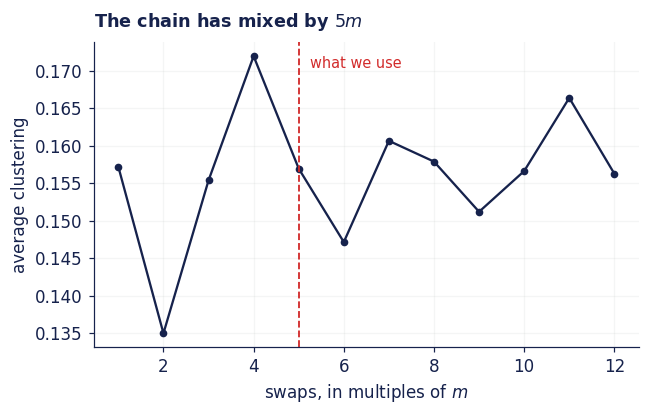

In [6]:
# mixing check: clustering as a function of how much we shuffle
trace = []
sw = GC.copy()
for step in range(12):
    nx.double_edge_swap(sw, nswap=m, max_tries=40*m, seed=700 + step)
    trace.append(nx.average_clustering(sw))

fig, ax = plt.subplots(figsize=(6.4, 3.6))
ax.plot(range(1, 13), trace, "o-", color=marvel.INK, ms=4)
ax.axvline(5, color=marvel.RED, ls="--", lw=1.2)
ax.text(5.25, max(trace), "what we use", color=marvel.RED, fontsize=9.5, va="top")
ax.set_xlabel("swaps, in multiples of $m$")
ax.set_ylabel("average clustering")
ax.set_title("The chain has mixed by $5m$", loc="left", fontsize=11.5,
             fontweight="bold", pad=10)
ax.grid(alpha=.18, color=marvel.RULE)
marvel.save(fig, 2, "mixing")
plt.show()

## 4. The scoreboard

For each quantity: the null mean, its spread, and the *z*-score — how many
standard deviations out the real value sits.

Watch the `pinned` rows. Three quantities come back from the shuffle with a
standard deviation of **exactly zero**, because they are functions of the degree
sequence alone and the shuffle preserves it by construction. There is no
distribution to compare against and no *z*-score to compute. A null model can be
incapable of disagreeing with you, and nothing in the number itself tells you so.

In [7]:
def column(tag, key):
    return np.array([r[tag][key] for r in reps], dtype=float)

ROWS = ["triangles", "C", "transitivity", "avg_dist",
        "assortativity", "fp_node", "diameter", "maxdeg", "isolates", "fp_edge"]

print(f"{'quantity':<16}{'real':>10} | {'G(n,m)':>17}{'z':>8} | {'shuffle':>17}{'z':>8}")
print("-" * 82)
for k in ROWS:
    line = f"{k:<16}{real[k]:>10.3f} |"
    for tag in ("er", "swap"):
        a = column(tag, k)
        z = marvel.zscore(real[k], a)
        zs = "pinned" if np.isnan(z) else f"{z:>8.1f}"
        line += f" {a.mean():>10.3f} ±{a.std():>6.3f}{zs:>8} |"
    print(line)

quantity              real |            G(n,m)       z |           shuffle       z
----------------------------------------------------------------------------------
triangles         1835.000 |    179.063 ±13.042   127.0 |   1186.490 ±45.974    14.1 |
C                    0.320 |      0.037 ± 0.003    92.9 |      0.155 ± 0.009    19.2 |
transitivity         0.182 |      0.037 ± 0.003    55.3 |      0.118 ± 0.005    14.1 |
avg_dist             2.674 |      2.663 ± 0.004     2.8 |      2.602 ± 0.016     4.6 |
assortativity       -0.105 |     -0.008 ± 0.026    -3.8 |     -0.122 ± 0.011     1.5 |
fp_node             24.897 |     11.224 ± 0.087   157.8 |     24.376 ± 0.544     1.0 |
diameter             6.000 |      4.387 ± 0.487     3.3 |      5.450 ± 0.561     1.0 |
maxdeg             106.000 |     20.310 ± 1.523    56.3 |    106.000 ± 0.000  pinned |
isolates             0.000 |      0.003 ± 0.058    -0.1 |      0.000 ± 0.000  pinned |
fp_edge             22.253 |     11.217 ± 0.079   1

## 5. Reciprocity — the directed case

39% of arrows in the Marvel network are mutual. Is that a lot?

This needs a null that preserves in- **and** out-degree separately, which
`double_edge_swap` cannot do. `marvel.directed_swap` is our implementation, and
the assertion below is the proof it does what it claims.

In [8]:
md_edges = G.number_of_edges()
real_recip = nx.reciprocity(G)
print(f"real reciprocity = {real_recip:.4f}")

# correctness: both degree sequences must survive the swap
E_swapped = marvel.directed_swap(G, 5 * md_edges, seed=1)
idx = {v: i for i, v in enumerate(G.nodes())}
E0 = np.array([[idx[a], idx[b]] for a, b in G.edges()])
for axis, label in [(0, "out"), (1, "in")]:
    before = np.sort(np.bincount(E0[:, axis], minlength=G.number_of_nodes()))
    after = np.sort(np.bincount(E_swapped[:, axis], minlength=G.number_of_nodes()))
    assert np.array_equal(before, after), f"{label}-degree not preserved"
    print(f"  {label}-degree preserved: True")

real reciprocity = 0.3924
  out-degree preserved: True
  in-degree preserved: True


In [9]:
def one_recip(seed):
    rng = np.random.default_rng(seed)
    E = marvel.directed_swap(G, 5 * md_edges, seed=int(rng.integers(1e9)))
    er = nx.gnm_random_graph(G.number_of_nodes(), md_edges,
                             seed=int(rng.integers(1e9)), directed=True)
    return {"swap": marvel.reciprocity_of(E), "er": nx.reciprocity(er)}

recip = marvel.cached("recip_reps", lambda: [one_recip(5000 + i) for i in range(N_REPS)])

for tag, label in [("er", "G(n,m) directed"), ("swap", "degree-preserving")]:
    a = np.array([r[tag] for r in recip])
    print(f"  vs {label:<18} {a.mean():.4f} ± {a.std():.4f}   "
          f"z = {marvel.zscore(real_recip, a):.1f}")

loaded 300 cached replicates from data/derived/recip_reps.jsonl
  vs G(n,m) directed    0.0194 ± 0.0047   z = 79.5
  vs degree-preserving  0.0578 ± 0.0066   z = 50.5


Reciprocity is the strongest survivor in the whole study. Keeping every
character's in- and out-degree gets you almost none of the way to 39%. Mutual
linking is an editorial habit — if A's article discusses its relationship with
B, B's article usually discusses the same relationship — and no amount of degree
bookkeeping predicts it.

## 6. Figures

### The histogram battery

wrote weeks/week2/figures/null_battery.svg


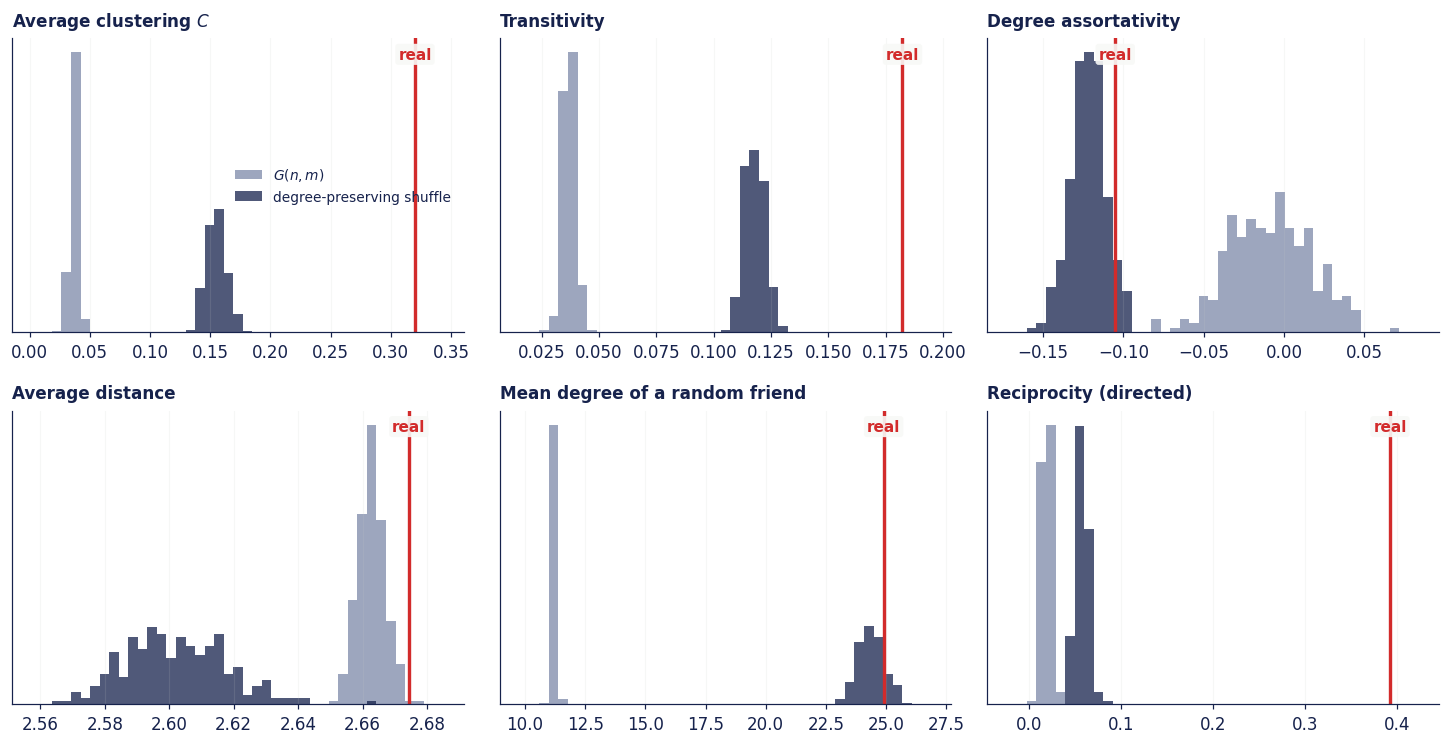

In [10]:
panels = [("C", "Average clustering $C$"), ("transitivity", "Transitivity"),
          ("assortativity", "Degree assortativity"), ("avg_dist", "Average distance"),
          ("fp_node", "Mean degree of a random friend"), ("RECIP", "Reciprocity (directed)")]

fig, axes = plt.subplots(2, 3, figsize=(13.4, 7.0))
for ax, (key, title) in zip(axes.ravel(), panels):
    if key == "RECIP":
        er = np.array([r["er"] for r in recip])
        sw = np.array([r["swap"] for r in recip])
        rv = real_recip
    else:
        er, sw, rv = column("er", key), column("swap", key), real[key]

    lo, hi = min(er.min(), sw.min(), rv), max(er.max(), sw.max(), rv)
    pad = (hi - lo) * .08 or .01
    bins = np.linspace(lo - pad, hi + pad, 44)

    ax.hist(er, bins=bins, color=GREY, alpha=.75, label="$G(n,m)$", edgecolor="none")
    ax.hist(sw, bins=bins, color=marvel.INK, alpha=.75,
            label="degree-preserving shuffle", edgecolor="none")
    ax.axvline(rv, color=marvel.RED, lw=2.2)
    ax.annotate("real", (rv, ax.get_ylim()[1] * .93), color=marvel.RED, fontsize=10,
                fontweight="bold", ha="center",
                bbox=dict(boxstyle="round,pad=.2", fc=marvel.CARD, ec="none", alpha=.9))
    ax.set_title(title, loc="left", fontsize=11, fontweight="bold", pad=8)
    ax.set_yticks([])
    ax.grid(alpha=.15, color=marvel.RULE, axis="x")

axes[0][0].legend(frameon=False, fontsize=9, loc="center right")
fig.tight_layout(pad=1.4)
marvel.save(fig, 2, "null_battery")
plt.show()

### Distance from chance

Note the symlog axis — the bars at the top are off the scale of the ones at the
bottom. The rows with no dark bar are the pinned ones.

wrote weeks/week2/figures/zscores.svg


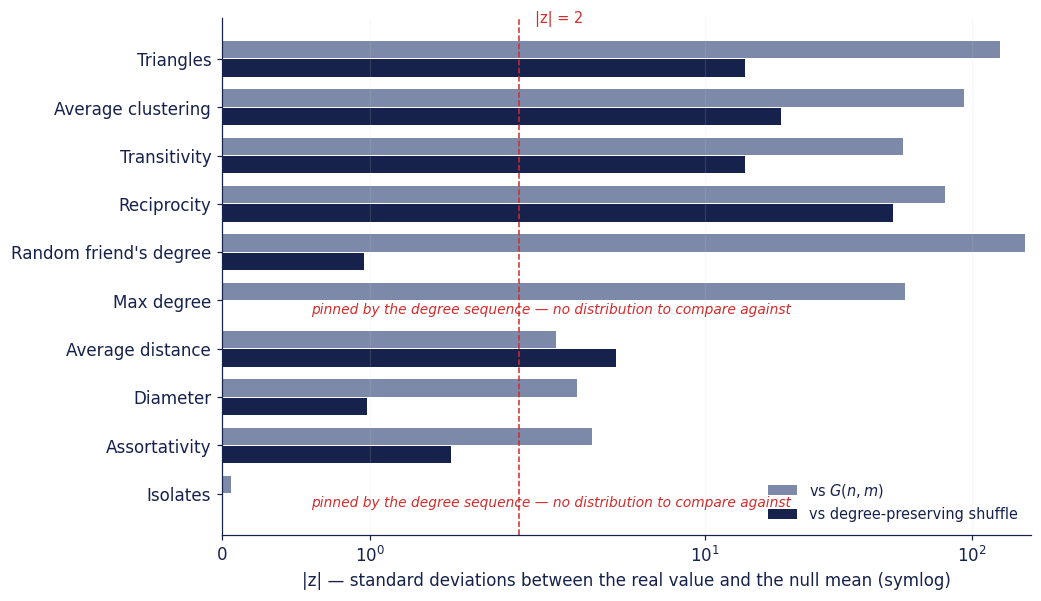

In [11]:
rows = [("Triangles", "triangles"), ("Average clustering", "C"),
        ("Transitivity", "transitivity"), ("Reciprocity", "RECIP"),
        ("Random friend's degree", "fp_node"), ("Max degree", "maxdeg"),
        ("Average distance", "avg_dist"), ("Diameter", "diameter"),
        ("Assortativity", "assortativity"), ("Isolates", "isolates")]

labels, z_er, z_sw, pinned = [], [], [], []
for title, k in rows:
    if k == "RECIP":
        er = np.array([r["er"] for r in recip])
        sw = np.array([r["swap"] for r in recip])
        rv = real_recip
    else:
        er, sw, rv = column("er", k), column("swap", k), real[k]
    labels.append(title)
    z_er.append(marvel.zscore(rv, er))
    z = marvel.zscore(rv, sw)
    pinned.append(np.isnan(z))
    z_sw.append(0.0 if np.isnan(z) else z)

y = np.arange(len(labels))[::-1]
fig, ax = plt.subplots(figsize=(9.6, 5.6))
ax.barh(y + .19, np.abs(z_er), height=.36, color=GREY, label="vs $G(n,m)$")
ax.barh(y - .19, np.abs(z_sw), height=.36, color=marvel.INK,
        label="vs degree-preserving shuffle")
for yy, f in zip(y, pinned):
    if f:
        ax.text(.6, yy - .19,
                "pinned by the degree sequence — no distribution to compare against",
                va="center", fontsize=9, color=marvel.RED, style="italic")
ax.axvline(2, color=marvel.RED, ls="--", lw=1)
ax.text(2.3, y[0] + .75, "|z| = 2", color=marvel.RED, fontsize=9.5)
ax.set_yticks(y); ax.set_yticklabels(labels)
ax.set_xscale("symlog", linthresh=2)
ax.set_xlabel("|z| — standard deviations between the real value and the null mean (symlog)")
ax.legend(frameon=False, fontsize=9.5, loc="lower right")
ax.grid(alpha=.15, color=marvel.RULE, axis="x")
fig.tight_layout()
marvel.save(fig, 2, "zscores")
plt.show()

### The friendship paradox is arithmetic

A random character has ⟨k⟩ links; a random neighbour has ⟨k⟩ + σ²/⟨k⟩. Both
terms are functions of the degree sequence, so the shuffle cannot move the
edge-picked version at all. The effect is huge and the *finding* is nil.

In [12]:
deg = dict(GC.degree())
k = np.array(list(deg.values()))
predicted = k.mean() + k.var() / k.mean()

print(f"  <k>                      = {k.mean():.2f}")
print(f"  sigma^2                  = {k.var():.1f}")
print(f"  <k> + sigma^2/<k>        = {predicted:.2f}   <- prediction")
print(f"  measured <k^2>/<k>       = {real['fp_edge']:.2f}   <- measurement")
assert abs(predicted - real["fp_edge"]) < 1e-9

strict = [v for v in GC if all(deg[w] <= deg[v] for w in GC[v])]
print(f"\ncharacters out-popularityed by NOBODY: {len(strict)}")
for v in strict:
    print(f"   {name[v]} (k = {deg[v]})")

  <k>                      = 10.26
  sigma^2                  = 123.0
  <k> + sigma^2/<k>        = 22.25   <- prediction
  measured <k^2>/<k>       = 22.25   <- measurement

characters out-popularityed by NOBODY: 1
   Spider-Man (k = 106)


wrote weeks/week2/figures/friendship.svg


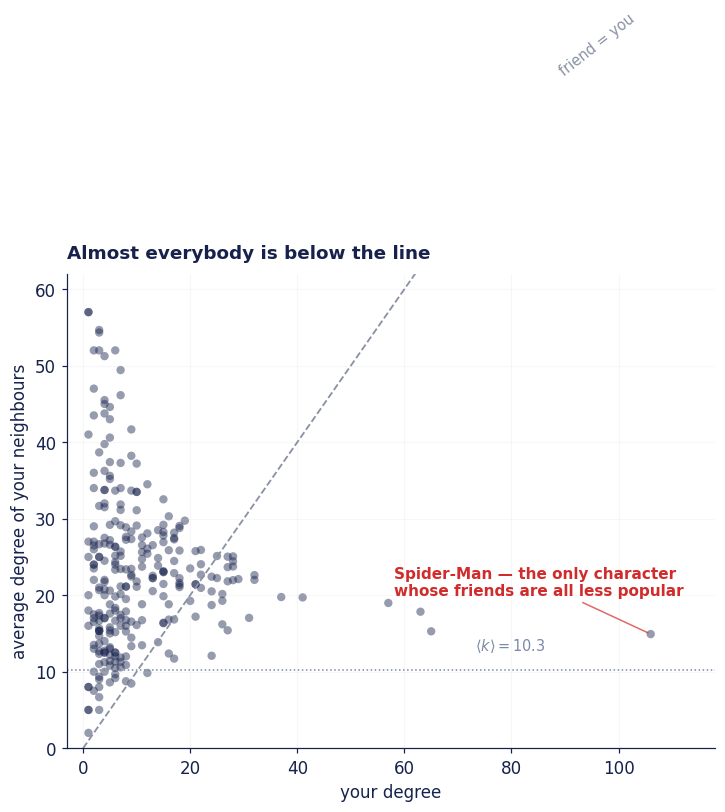

242 of 277 characters have more popular friends on average


In [13]:
you = np.array([deg[v] for v in GC])
friend = np.array([np.mean([deg[w] for w in GC[v]]) for v in GC])

fig, ax = plt.subplots(figsize=(7.6, 5.6))
ax.scatter(you, friend, s=30, color=marvel.INK, alpha=.45, edgecolors="none")
ax.plot([0, 118], [0, 118], "--", color=marvel.MUTED, lw=1.2)
ax.text(96, 88, "friend = you", color=marvel.MUTED, fontsize=9.5, rotation=38, ha="center")
ax.axhline(you.mean(), color=GREY, lw=1, ls=":")
ax.text(118*.62, you.mean() + 2.5, r"$\langle k \rangle = 10.3$", color=GREY, fontsize=9.5)

sm = next(v for v in GC if deg[v] == 106)
ax.annotate("Spider-Man — the only character\nwhose friends are all less popular",
            (deg[sm], friend[list(GC).index(sm)]), xytext=(58, 20), fontsize=10,
            color=marvel.RED, fontweight="bold",
            arrowprops=dict(arrowstyle="-", color=marvel.RED, lw=1, alpha=.7))

ax.set_xlim(-3, 118); ax.set_ylim(0, 62)
ax.set_xlabel("your degree")
ax.set_ylabel("average degree of your neighbours")
ax.set_title("Almost everybody is below the line", loc="left",
             fontsize=12, fontweight="bold", pad=10)
ax.grid(alpha=.15, color=marvel.RULE)
marvel.save(fig, 2, "friendship")
plt.show()

print(f"{(friend > you).sum()} of {len(you)} characters have more popular friends on average")

## 7. The power-law question

Week 1 noted the in-degree looked roughly straight on log–log axes. The CCDF —
the fraction of characters with degree at least *k* — needs no binning and uses
every data point, so it is the honest way to look at a tail.

wrote weeks/week2/figures/ccdf.svg


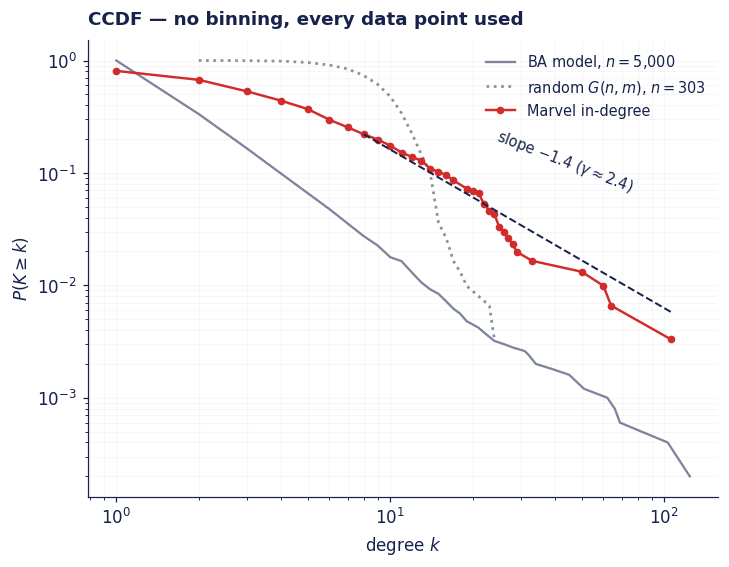

In [14]:
ind = np.array([d for _, d in G.in_degree()])
ba = np.array([d for _, d in nx.barabasi_albert_graph(5000, 1, seed=3).degree()])
er_deg = np.array([d for _, d in nx.gnm_random_graph(303, 1434, seed=3).degree()])

def ccdf(a):
    x = np.sort(np.unique(a[a > 0]))
    return x, np.array([(a >= t).mean() for t in x])

fig, ax = plt.subplots(figsize=(7.4, 5.4))
x, y = ccdf(ba)
ax.loglog(x, y, "-", color=marvel.INK, lw=1.5, alpha=.55, label="BA model, $n=5{,}000$")
x, y = ccdf(er_deg)
ax.loglog(x, y, ":", color=marvel.MUTED, lw=1.8, label="random $G(n,m)$, $n=303$")
x, y = ccdf(ind)
ax.loglog(x, y, "o-", color=marvel.RED, ms=4, lw=1.6, label="Marvel in-degree")

anchor = (ind >= 8).mean()
xs = np.array([8., 106.])
ax.loglog(xs, anchor * (xs/8.)**(-1.41), "--", color=marvel.INK, lw=1.3)
ax.text(24, anchor * (24/8.)**(-1.41) * 1.45, r"slope $-1.4$ ($\gamma \approx 2.4$)",
        color=marvel.INK, fontsize=9.5, rotation=-21)

ax.set_xlabel("degree $k$"); ax.set_ylabel(r"$P(K \geq k)$")
ax.set_title("CCDF — no binning, every data point used", loc="left",
             fontsize=12, fontweight="bold", pad=10)
ax.legend(frameon=False, fontsize=9.5)
ax.grid(alpha=.15, color=marvel.RULE, which="both")
marvel.save(fig, 2, "ccdf")
plt.show()

### The exponent is whatever you want it to be

Maximum likelihood gives a γ for any choice of where the tail starts. Varying
that choice is the check most fits skip.

wrote weeks/week2/figures/gamma_kmin.svg


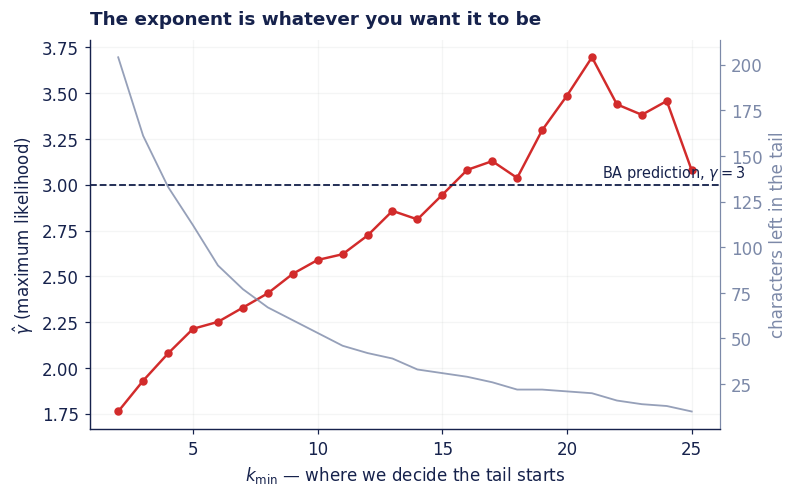

gamma ranges from 1.76 to 3.70 over kmin 2..25
We can report 'gamma = 3, consistent with preferential attachment' by
choosing kmin = 15. It would be true, and it would be worthless.


In [15]:
def mle_gamma(a, kmin):
    tail = a[a >= kmin]
    return 1 + len(tail) / np.sum(np.log(tail / (kmin - 0.5))), len(tail)

kmins = np.arange(2, 26)
gammas, tails = zip(*(mle_gamma(ind, km) for km in kmins))

fig, ax = plt.subplots(figsize=(7.4, 4.6))
ax.plot(kmins, gammas, "o-", color=marvel.RED, ms=4.5, lw=1.6)
ax.axhline(3, color=marvel.INK, ls="--", lw=1.2)
ax.text(21.4, 3.04, "BA prediction, $\\gamma = 3$", color=marvel.INK, fontsize=9.5)

ax2 = ax.twinx()
ax2.plot(kmins, tails, color=GREY, lw=1.2, alpha=.8)
ax2.set_ylabel("characters left in the tail", color=GREY)
ax2.tick_params(colors=GREY)
ax2.spines["right"].set_visible(True)
ax2.spines["right"].set_color(GREY)

ax.set_xlabel("$k_{\\min}$ — where we decide the tail starts")
ax.set_ylabel("$\\hat{\\gamma}$ (maximum likelihood)")
ax.set_title("The exponent is whatever you want it to be", loc="left",
             fontsize=12, fontweight="bold", pad=10)
ax.grid(alpha=.18, color=marvel.RULE)
marvel.save(fig, 2, "gamma_kmin")
plt.show()

print(f"gamma ranges from {min(gammas):.2f} to {max(gammas):.2f} over kmin 2..25")
print("We can report 'gamma = 3, consistent with preferential attachment' by")
print("choosing kmin = 15. It would be true, and it would be worthless.")